# Slippage Demo

This notebook demonstrates how slippage affects market making profitability using the `generate_quotes_with_slippage` method.

**Slippage** is the difference between the expected price of a trade and the actual execution price. For market makers, slippage is always adverse:
- Buy orders: you pay **more** than expected
- Sell orders: you receive **less** than expected

In [1]:
import sys
sys.path.insert(0, 'build')

import hft_core
import matplotlib.pyplot as plt
import numpy as np

## 1. Setup: Market Data

Create a market with a 5-cent spread.

In [2]:
market = hft_core.MarketDataHandler()
market.update_bid(100.00, 100)
market.update_ask(100.05, 100)

print(f"Best Bid:  {market.get_best_bid():.2f}")
print(f"Best Ask:  {market.get_best_ask():.2f}")
print(f"Mid Price: {market.get_mid_price():.4f}")
print(f"Spread:    {market.get_spread():.4f}")

Best Bid:  100.00
Best Ask:  100.05
Mid Price: 100.0250
Spread:    0.0500


## 2. Slippage Explained

Without slippage, the market maker's quote price equals the fill price. With slippage, the fill price is worse:

| Order Side | Quote Price | Fill Price | Effect |
|-----------|-------------|------------|--------|
| Buy       | $P_{buy}$   | $P_{buy} + \text{slippage}$ | Pay more  |
| Sell      | $P_{sell}$  | $P_{sell} - \text{slippage}$ | Receive less |

Slippage is specified in **basis points (bps)** where 1 bps = 0.01%.
For example, `slippage_bps=5` means 0.05% adverse price movement.

In [3]:
mm = hft_core.SimpleMarketMaker(0.2, 50)

buy_no_slip, sell_no_slip = mm.generate_quotes(market)
buy_slip, sell_slip = mm.generate_quotes_with_slippage(market, 5)

print("=== Without Slippage ===")
print(f"  Buy  quote: {buy_no_slip.price:.4f}  fill: {buy_no_slip.fill_price:.4f}")
print(f"  Sell quote: {sell_no_slip.price:.4f}  fill: {sell_no_slip.fill_price:.4f}")
print(f"  Round-trip profit: {sell_no_slip.fill_price - buy_no_slip.fill_price:.4f}")

print("\n=== With 5 bps Slippage ===")
print(f"  Buy  quote: {buy_slip.price:.4f}  fill: {buy_slip.fill_price:.4f}  (adverse: +{buy_slip.fill_price - buy_slip.price:.4f})")
print(f"  Sell quote: {sell_slip.price:.4f}  fill: {sell_slip.fill_price:.4f}  (adverse: {sell_slip.fill_price - sell_slip.price:.4f})")
print(f"  Round-trip profit: {sell_slip.fill_price - buy_slip.fill_price:.4f}")

profit_loss = (sell_no_slip.fill_price - buy_no_slip.fill_price) - (sell_slip.fill_price - buy_slip.fill_price)
print(f"\nSlippage cost per round-trip: {profit_loss:.4f}")

=== Without Slippage ===
  Buy  quote: 100.0050  fill: 100.0050
  Sell quote: 100.0450  fill: 100.0450
  Round-trip profit: 0.0400

=== With 5 bps Slippage ===
  Buy  quote: 100.0050  fill: 100.0550  (adverse: +0.0500)
  Sell quote: 100.0450  fill: 99.9950  (adverse: -0.0500)
  Round-trip profit: -0.0601

Slippage cost per round-trip: 0.1001


## 3. Visualize Quote Price vs Fill Price

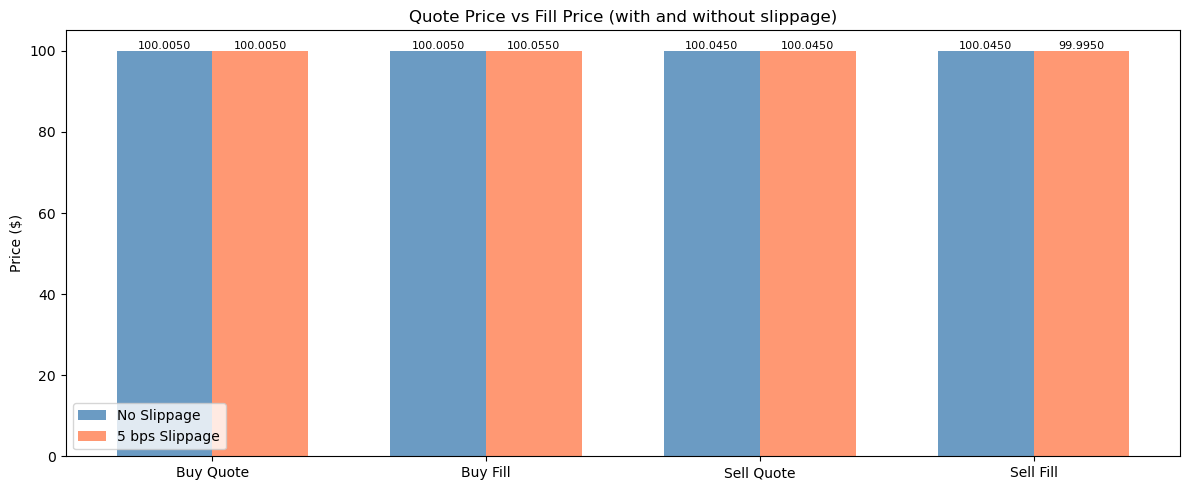

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(4)
labels = ['Buy Quote', 'Buy Fill', 'Sell Quote', 'Sell Fill']
no_slip = [buy_no_slip.price, buy_no_slip.fill_price, sell_no_slip.price, sell_no_slip.fill_price]
with_slip = [buy_slip.price, buy_slip.fill_price, sell_slip.price, sell_slip.fill_price]

width = 0.35
bars1 = ax.bar(x - width/2, no_slip, width, label='No Slippage', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, with_slip, width, label='5 bps Slippage', color='coral', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Price ($)')
ax.set_title('Quote Price vs Fill Price (with and without slippage)')
ax.legend()

for bar_group in [bars1, bars2]:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Profit Erosion Across Slippage Levels

How does increasing slippage erode the market maker's profit?

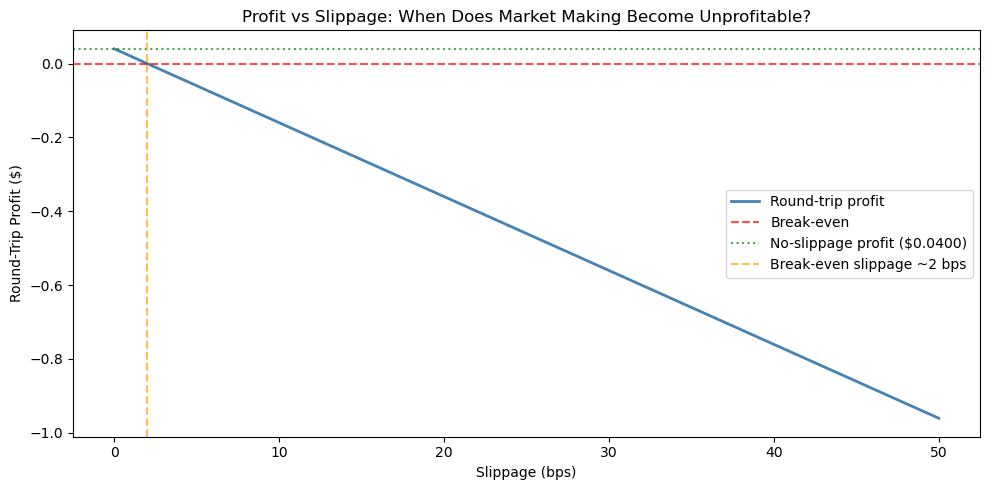

In [5]:
slippage_levels = np.arange(0, 51, 1)  # 0 to 50 bps
profits = []

for bps in slippage_levels:
    buy, sell = mm.generate_quotes_with_slippage(market, float(bps))
    round_trip = sell.fill_price - buy.fill_price
    profits.append(round_trip)

base_profit = sell_no_slip.fill_price - buy_no_slip.fill_price

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(slippage_levels, profits, linewidth=2, color='steelblue', label='Round-trip profit')
ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='Break-even')
ax.axhline(base_profit, color='green', linestyle=':', alpha=0.7, label=f'No-slippage profit (${base_profit:.4f})')

breakeven_idx = np.argmin(np.abs(np.array(profits)))
breakeven_bps = slippage_levels[breakeven_idx]
ax.axvline(breakeven_bps, color='orange', linestyle='--', alpha=0.7, label=f'Break-even slippage ~{breakeven_bps} bps')

ax.set_xlabel('Slippage (bps)')
ax.set_ylabel('Round-Trip Profit ($)')
ax.set_title('Profit vs Slippage: When Does Market Making Become Unprofitable?')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Slippage Impact Across Different inside_pct Values

Market makers using different `inside_pct` face different slippage risks. Tighter quotes (lower inside_pct) have more profit cushion against slippage.

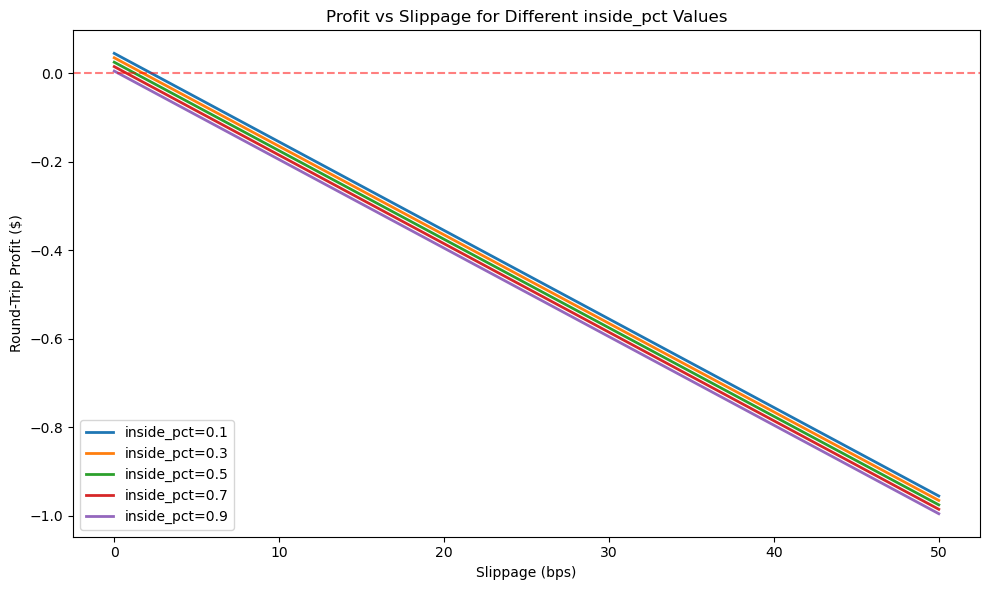

In [6]:
inside_values = [0.1, 0.3, 0.5, 0.7, 0.9]
slippage_range = np.arange(0, 51, 1)

fig, ax = plt.subplots(figsize=(10, 6))

for inside in inside_values:
    mm_temp = hft_core.SimpleMarketMaker(inside, 50)
    profits_temp = []
    for bps in slippage_range:
        buy, sell = mm_temp.generate_quotes_with_slippage(market, float(bps))
        profits_temp.append(sell.fill_price - buy.fill_price)
    ax.plot(slippage_range, profits_temp, linewidth=2, label=f'inside_pct={inside}')

ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Slippage (bps)')
ax.set_ylabel('Round-Trip Profit ($)')
ax.set_title('Profit vs Slippage for Different inside_pct Values')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Effective Spread Capture

Slippage reduces the effective spread that the market maker captures. We can express the captured fraction as:

$$\text{Captured Fraction} = \frac{\text{Fill Sell} - \text{Fill Buy}}{\text{Quote Sell} - \text{Quote Buy}}$$

A captured fraction below 1 means slippage is eating into profits; below 0 means losses.

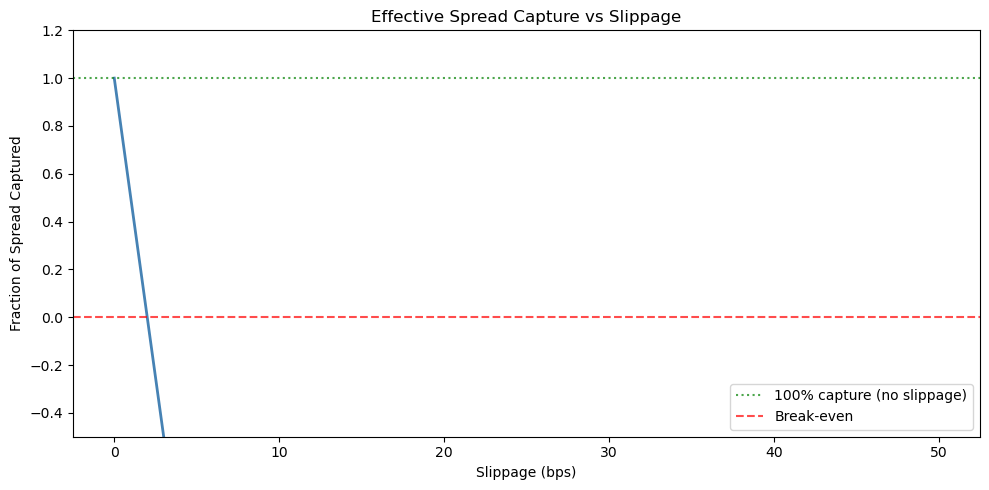

In [7]:
slippage_levels = np.arange(0, 51, 1)
captured_fractions = []

quote_spread = sell_no_slip.price - buy_no_slip.price

for bps in slippage_levels:
    buy, sell = mm.generate_quotes_with_slippage(market, float(bps))
    fill_spread = sell.fill_price - buy.fill_price
    captured_fractions.append(fill_spread / quote_spread if quote_spread != 0 else 0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(slippage_levels, captured_fractions, linewidth=2, color='steelblue')
ax.axhline(1.0, color='green', linestyle=':', alpha=0.7, label='100% capture (no slippage)')
ax.axhline(0.0, color='red', linestyle='--', alpha=0.7, label='Break-even')

ax.set_xlabel('Slippage (bps)')
ax.set_ylabel('Fraction of Spread Captured')
ax.set_title('Effective Spread Capture vs Slippage')
ax.legend()
ax.set_ylim(-0.5, 1.2)

plt.tight_layout()
plt.show()

## 7. Monte Carlo: Profit Distribution Under Random Slippage

In practice, slippage varies from trade to trade. Let's simulate a market maker doing many round-trips with random slippage drawn from a normal distribution.

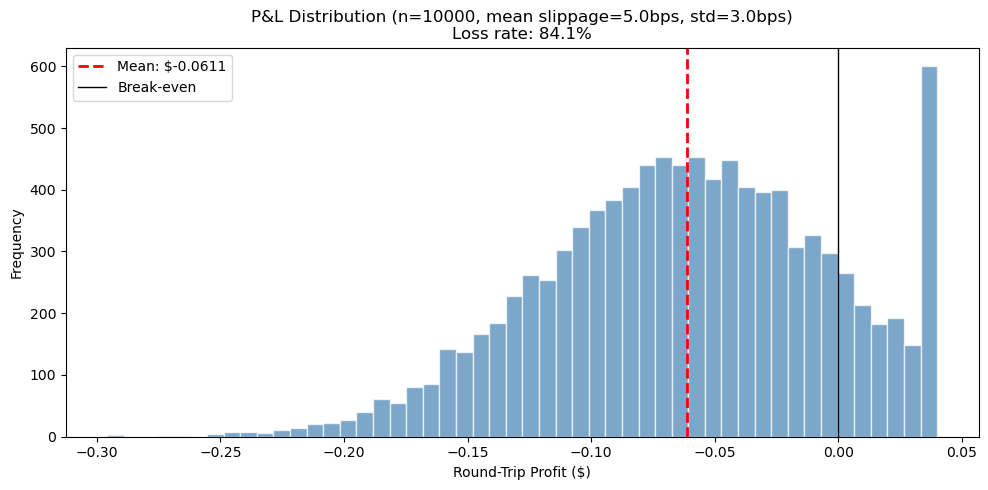

In [10]:
np.random.seed(42)
n_trades = 10000
mean_slippage_bps = 5.0
std_slippage_bps = 3.0

random_slippage = np.random.normal(mean_slippage_bps, std_slippage_bps, n_trades)
random_slippage = np.maximum(random_slippage, 0)  # Slippage can't be negative

pnl_per_trade = []
for bps in random_slippage:
    buy, sell = mm.generate_quotes_with_slippage(market, float(bps))
    pnl_per_trade.append(sell.fill_price - buy.fill_price)

pnl_per_trade = np.array(pnl_per_trade)

fig, ax = plt.subplots(figsize=(10, 5))
n_bins = 50
ax.hist(pnl_per_trade, bins=n_bins, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(np.mean(pnl_per_trade), color='red', linestyle='--', linewidth=2, label=f'Mean: ${np.mean(pnl_per_trade):.4f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1, label='Break-even')

loss_pct = np.mean(pnl_per_trade < 0) * 100
ax.set_xlabel('Round-Trip Profit ($)')
ax.set_ylabel('Frequency')
ax.set_title(f'P&L Distribution (n={n_trades}, mean slippage={mean_slippage_bps}bps, std={std_slippage_bps}bps)\nLoss rate: {loss_pct:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

## 8. Cumulative P&L Over Simulated Trades

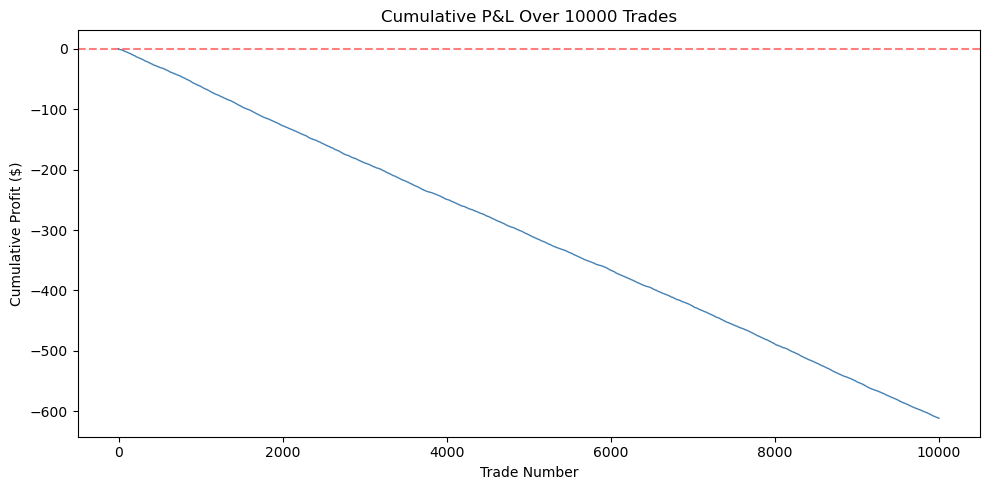

Final P&L: $-611.49
Average P&L per trade: $-0.0611
Sharpe-like ratio (mean/std): -1.06


In [11]:
cumulative_pnl = np.cumsum(pnl_per_trade)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cumulative_pnl, linewidth=1, color='steelblue')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Trade Number')
ax.set_ylabel('Cumulative Profit ($)')
ax.set_title(f'Cumulative P&L Over {n_trades} Trades')

plt.tight_layout()
plt.show()

print(f"Final P&L: ${cumulative_pnl[-1]:.2f}")
print(f"Average P&L per trade: ${np.mean(pnl_per_trade):.4f}")
print(f"Sharpe-like ratio (mean/std): {np.mean(pnl_per_trade)/np.std(pnl_per_trade):.2f}")

---

## Summary

| Concept | Key Insight |
|---------|-------------|
| **Slippage** | Adverse price movement between quote and fill |
| **Buy impact** | Pay more than quoted price |
| **Sell impact** | Receive less than quoted price |
| **Profit erosion** | Slippage directly reduces round-trip profit |
| **Break-even** | Slippage level where profit = 0 |
| **Captured fraction** | Fraction of the spread the MM keeps after slippage |
| **Distribution** | Random slippage creates P&L uncertainty |